# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

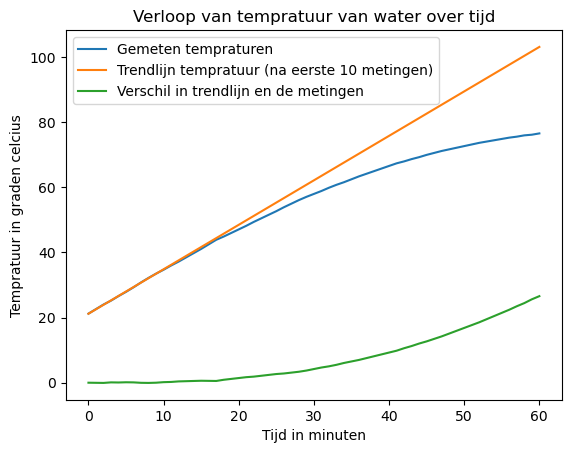

In [61]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

fn = 'tempmetingen-4cf186212764ab8cff768190b1cc613a.csv'

data = []
test = np.array([1,2,3,4,5,6,7,8])
regel2 = [0,0]

m_beker = 820.8
m_totaal_start = 1292.9
m_water = m_totaal_start - m_beker 
c_water = 4.18 

with open(fn, mode='r', newline='', encoding='utf-8') as bestand:
        file = csv.reader(bestand, delimiter=';')
        for regel in file:
            data.append(regel)

npda = np.array(data)
datax = npda[1:, 0].astype(float)
datay = npda[1:, 1].astype(float)

a, b = np.polyfit(datax[:10], datay[:10], 1)
def verwachting(t, T_start, helling):
    return T_start + helling * t

tempv = verwachting(datax, b, a)

diff = tempv - datay


plt.Figure(figsize=[5,8])
plt.plot(datax,datay, label="Gemeten tempraturen ")
plt.plot(datax,tempv, label = "Trendlijn tempratuur (na eerste 10 metingen)")
plt.plot(datax,diff, label = "Verschil in trendlijn en de metingen")
plt.xlabel('Tijd in minuten')
plt.ylabel('Tempratuur in graden celcius')
plt.title('Verloop van tempratuur van water over tijd')
plt.legend()
plt.show()
            

> * **Toegevoegde energie:** 
Berekend via de helling van de eerste 10 minuten (toen verlies nog minimaal was): 162 kJ.
> * **Gebruikte energie:**
> * Opwarming water: 109 kJ
> * Verdamping water: 41 kJ
> * Deze berekeningen geven een gat van 12kJ tussen de berekende waarda van totale energie, en van de twee onderverdelingen, dat betekend dat óf de berekeningen niet kloppen, óf dat er 12kJ aan warmteverlies naar de omgeving is gegaan

> **Gemaakte aannames:**
> 1. Het vermogen van het verwarmingselement is constant gedurende het hele experiment.
> 2. Het warmte verlies gedurende de eerste tien minuten aan verdamping verwaarloosbaar is
> 3. De soortelijke warmte () van water is constant bij stijgende temperatuur.

> **Aanbevelingen voor verbetering:**
> 1. **Isolatie:** Verbeterde isolatie zorgt er voor dat er minimale warmteverlies is, wat de resultaten bruikbaarder maakt.
> 2. **Deksel:** Voeg een deksel toe om verdamping tegen te gaan, om zo resultaten met en zonder verdamping te kunnen vergelijken
> 3. **Directe vermogensmeting:** In plaats van het vermogen te schatten via de temperatuurstijging, sluit een Joulemeter  aan op het verwarmingselement. Zo weet je exact hoeveel elektrische energie erin gaat, onafhankelijk van watermassa of verliezen.
